---
title: "Tutorial 1 (Introductory): Visualizing Timeseries"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

Now that you've learned the fundamentals of neuroimaging and the connectomics workflow—including concepts such as fMRI timeseries, brain parcellation, and functional connectivity (FC)—it's time to put those ideas into practice using LEMON dataset. In this notebook, we'll learn how to load, explore, subset, and visualize brain timeseries data using common Python libraries.

# Working with Timeseries Data

In this notebook, we will:

1. Load a CSV file from the `ts/` folder inside our project directory
2. Inspect the data
3. Get the Schaefer atlas region names with nilearn
4. Subset one subject
5. Subset one brain region
6. Plot that region’s activity over time

```{note}
Before running this notebook, make sure the required Python packages are installed (e.g., **NumPy**, **Pandas**, **Matplotlib**, and **Nilearn**). If you're unsure how to install them, please refer to the **Connectome2026 Programming Guide** or the official documentation for each package, which provides instructions for installation using **conda** and/or **pip**.
```


Below, we'll be importing some python packages that are required for this script. Common packages are 
* numpy and pandas to deal with numbers and dataframes (i.e., tables)
* matplotlib for data visualization
* pathlib for managing your file paths/directories
* nilearn for anything to do with neuroimaging data

Feel free to run the code below to "import" these packages, which is a way to let the code knows that we'll be using these specific packages.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.datasets import fetch_atlas_schaefer_2018

## 1. Set Up the File Path

First, we will define the directory where **this** notebook is using the function or command "cwd" from the "Path" package that we have imported from above `from pathlib import Path`

cwd = current working directory

We'll be calling this current working directory as your **project directory**. 

Then, where your code is, create a folder called "ts". Within this folder "ts", we'll store our timeseries file in Schaefer parcellation (`schaefer100_timeseries_long.csv`). 

With this, try to understand what the code below is doing! 

In [2]:
PROJECT_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026") # assign the main directory containing your data to the PROJECT_DIR variable
# PROJECT_DIR = Path.cwd() # OR assign your directory of this code to `PROJECT_DIR` variable
TS_DIR = PROJECT_DIR / "ts" # a variable indicating where your timeseries data is (i.e., in the "ts" folder)
CSV_FILE = TS_DIR / "schaefer100_timeseries_long.csv" # a variable specifying the exact location of your timeseries file

print("Project directory:", PROJECT_DIR) # using Python in-built "print" function to print your project directory
print("Timeseries file:", CSV_FILE) # using Python in-built "print" function to print the location of your csv timeseries file

Project directory: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026
Timeseries file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/ts/schaefer100_timeseries_long.csv


## 2. Load the CSV File

Next, we need to convert (or import) the csv file into a "dataframe" format.

A DataFrame is like a spreadsheet: rows and columns are organized in a table. Dataframes make it easy for us to manipulate large datasets with many rows and columns. 

We use `pandas.read_csv()` to import the data into a DataFrame (i.e., `read_csv` function from the `pandas` package)

If you have imported the packages and indicated your file paths correctly, you should be able to run the code below. 

In [3]:
timeseries_df = pd.read_csv(CSV_FILE) # import our csv file into a dataframe

print("Shape of dataframe:", timeseries_df.shape) # using `shape` (from pandas) to see the dimensions/size of the dataframe + print the results
timeseries_df.head() # see the first few rows of the dataframe using `head` from pandas

Shape of dataframe: (143440, 101)


,subject,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
0,sub-010002,0.237821,0.220440,0.186688,0.297754,0.484658,-0.002499,0.529288,0.499871,0.148403,...,-0.091226,0.683757,0.328559,0.039470,0.131935,0.043597,0.066287,0.071194,0.948359,0.183499
1,sub-010002,0.286141,-0.054204,-0.024814,-0.067862,0.101375,-0.209323,0.400933,0.178843,-0.113703,...,-0.087884,0.709039,0.290263,-0.029627,0.230706,0.081735,0.236640,0.130366,0.776084,0.193015
2,sub-010002,0.274276,-0.137804,-0.127747,-0.197268,-0.023573,-0.334204,0.378606,0.083082,-0.236721,...,-0.055982,0.654355,0.265140,-0.026525,0.285150,0.095764,0.361930,0.127323,0.621242,0.177065
3,sub-010002,0.231568,-0.085922,-0.122859,-0.170150,0.007600,-0.330031,0.366392,0.110435,-0.222152,...,-0.026843,0.565333,0.272916,0.037913,0.385028,0.123310,0.482218,0.096348,0.462415,0.150757
4,sub-010002,0.143568,0.000638,-0.061845,-0.086502,0.116202,-0.230028,0.325637,0.215286,-0.105178,...,-0.036879,0.419035,0.240595,0.056467,0.424269,0.060492,0.517564,0.000655,0.250562,0.038837


## 3. Understand the Structure of the Dataframe

Now that we have imported the timeseries data from the csv into the dataframe format (stored in the `timeseries_df` variable), let's try to make sense of our dataframe or the timeseries data! 

### Dimension
First, let's check the shape or the dimension of the dataframe using `.shape` from pandas. 

In [5]:
print("Shape of dataframe:", timeseries_df.shape) # using `shape` (from pandas) to see the dimensions/size of the dataframe + print the results

Shape of dataframe: (143440, 101)


This returns: `(143440, 101)`. Recall that a dataframe's shape is reported as: `(number_of_rows, number_of_columns)`. Therefore, our dataset contains **143,440 rows** and **101 columns**

The 101 columns consist of:

- 1 column containing the subject ID (`subject`)
- 100 columns containing brain activity values from the Schaefer100 atlas regions

The 143,440 rows contain data from **all subjects combined**.

Since this dataset contains **220 subjects**, each with **652 fMRI time points**, we have: `220 subjects × 652 time points = 143,440 rows`

In other words, this CSV file stores the complete timeseries dataset for every participant in a single table.

### Previewing Your Dataframe
Timeseries data from neuroimaging is often very large. However, we can use `head` from pandas to see the first few rows and some columns from our dataframe. 

In [6]:
timeseries_df.head() # see the first few rows of the dataframe using `head` from pandas

,subject,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
0,sub-010002,0.237821,0.220440,0.186688,0.297754,0.484658,-0.002499,0.529288,0.499871,0.148403,...,-0.091226,0.683757,0.328559,0.039470,0.131935,0.043597,0.066287,0.071194,0.948359,0.183499
1,sub-010002,0.286141,-0.054204,-0.024814,-0.067862,0.101375,-0.209323,0.400933,0.178843,-0.113703,...,-0.087884,0.709039,0.290263,-0.029627,0.230706,0.081735,0.236640,0.130366,0.776084,0.193015
2,sub-010002,0.274276,-0.137804,-0.127747,-0.197268,-0.023573,-0.334204,0.378606,0.083082,-0.236721,...,-0.055982,0.654355,0.265140,-0.026525,0.285150,0.095764,0.361930,0.127323,0.621242,0.177065
3,sub-010002,0.231568,-0.085922,-0.122859,-0.170150,0.007600,-0.330031,0.366392,0.110435,-0.222152,...,-0.026843,0.565333,0.272916,0.037913,0.385028,0.123310,0.482218,0.096348,0.462415,0.150757
4,sub-010002,0.143568,0.000638,-0.061845,-0.086502,0.116202,-0.230028,0.325637,0.215286,-0.105178,...,-0.036879,0.419035,0.240595,0.056467,0.424269,0.060492,0.517564,0.000655,0.250562,0.038837


Using `head()`, we can see from the above that the first column contains the subject ID, while the remaining columns contain activity values from Schaefer100 brain regions (for example, `7Networks_LH_Vis_1`, `7Networks_LH_Vis_2`, and so on).

Each row represents a **single fMRI time point** from one subject:

- each row = one fMRI time point
- first column = subject identifier
- remaining columns = brain activity values for each Schaefer100 brain region
- consecutive rows for the same subject form that subject's fMRI timeseries (we'll be visualizing this timeseries later!)

Remember, all subjects are stored together in the same dataframe. 

To gain some more intuition to this dataset, let's do two things:
* get a list of column names and subject names
* extract the data just for a **single subject** and explore their timeseries before moving on to analyses involving the full dataset.

Each row represents a **single fMRI time point** from one subject:

- each row = one fMRI time point
- first column = subject identifier
- remaining columns = brain activity values for each Schaefer100 brain region
- consecutive rows for the same subject form that subject's fMRI timeseries (we'll be visualizing this timeseries later!)

Remember, all subjects are stored together in the same dataframe. 

To gain some more intuition to this dataset, let's do two things:
* get a list of column names and subject names
* extract the data just for a **single subject** and explore their timeseries before moving on to analyses involving the full dataset.

### List of Brain Regions (Columns) and Subject Ids (Rows)

**Columns (brain regions)**

Recall that each column corresponds to either:

- the subject identifier (`subject`)
- a Schaefer100 brain region

The code below converts the dataframe's column names into a Python list and prints them.

A **list** is one of Python's basic data structures used to store multiple items in a **specific order**. You can think of a list like a numbered collection, where each item has a position and can be accessed individually.

For example, a list can store many brain region names, allowing us to access, inspect, or loop through them one at a time.

For the code below, all you need to know is that we are applying `.tolist()` to the dataframe to create a new list containing all their column names. 

In [7]:
# Get a list containing all column names in the dataframe
column_names = timeseries_df.columns.tolist() # uses .tolist

# Print the list
print(column_names)

['subject', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5', '7Networks_LH_Vis_6', '7Networks_LH_Vis_7', '7Networks_LH_Vis_8', '7Networks_LH_Vis_9', '7Networks_LH_SomMot_1', '7Networks_LH_SomMot_2', '7Networks_LH_SomMot_3', '7Networks_LH_SomMot_4', '7Networks_LH_SomMot_5', '7Networks_LH_SomMot_6', '7Networks_LH_DorsAttn_Post_1', '7Networks_LH_DorsAttn_Post_2', '7Networks_LH_DorsAttn_Post_3', '7Networks_LH_DorsAttn_Post_4', '7Networks_LH_DorsAttn_Post_5', '7Networks_LH_DorsAttn_Post_6', '7Networks_LH_DorsAttn_PrCv_1', '7Networks_LH_DorsAttn_FEF_1', '7Networks_LH_SalVentAttn_ParOper_1', '7Networks_LH_SalVentAttn_FrOperIns_1', '7Networks_LH_SalVentAttn_FrOperIns_2', '7Networks_LH_SalVentAttn_PFCl_1', '7Networks_LH_SalVentAttn_Med_1', '7Networks_LH_SalVentAttn_Med_2', '7Networks_LH_SalVentAttn_Med_3', '7Networks_LH_Limbic_OFC_1', '7Networks_LH_Limbic_TempPole_1', '7Networks_LH_Limbic_TempPole_2', '7Networks_LH_Cont_Par_1', '7Netw

**Obtaining list of unique subject IDs**:

Let's try to obtain a list of unique subject IDs. 

The results from the `print(column_names)` show that the first column is the 'subject' column. (Remember, list stores values in a **specific order**). 

The dataframe contains many rows for each subject because every subject has multiple fMRI time points.

For example, subject `sub-010002` may appear 652 times because that participant has 652 time points.

If we simply print the `subject` column, we would see many repeated subject IDs. The output shown after printing the subject column shows that there are 143440 rows (`Length: 143440`). 

In [8]:
# Subset the subject column of the timeseries dataframe
subject_column = timeseries_df["subject"]

print(subject_column) # display subject_column

0         sub-010002
1         sub-010002
2         sub-010002
3         sub-010002
4         sub-010002
             ...    
143435    sub-010321
143436    sub-010321
143437    sub-010321
143438    sub-010321
143439    sub-010321
Name: subject, Length: 143440, dtype: str


So the next step is to find unique or distinct subject IDs that appear in `subject_column`. 

In pandas, we can use `.unique()` to find distinct values in a single column, which is what we need to find distinct subject IDs that appear in `subject_column`. 

In [9]:
# Get the unique values that appear in that column
subject_ids = subject_column.unique().tolist()

subject_ids

['sub-010002',
 'sub-010003',
 'sub-010004',
 'sub-010005',
 'sub-010006',
 'sub-010007',
 'sub-010010',
 'sub-010012',
 'sub-010015',
 'sub-010016',
 'sub-010017',
 'sub-010019',
 'sub-010020',
 'sub-010021',
 'sub-010022',
 'sub-010023',
 'sub-010024',
 'sub-010026',
 'sub-010027',
 'sub-010028',
 'sub-010029',
 'sub-010030',
 'sub-010031',
 'sub-010032',
 'sub-010033',
 'sub-010034',
 'sub-010035',
 'sub-010036',
 'sub-010037',
 'sub-010038',
 'sub-010039',
 'sub-010040',
 'sub-010041',
 'sub-010042',
 'sub-010043',
 'sub-010044',
 'sub-010045',
 'sub-010046',
 'sub-010048',
 'sub-010050',
 'sub-010051',
 'sub-010052',
 'sub-010053',
 'sub-010056',
 'sub-010059',
 'sub-010060',
 'sub-010061',
 'sub-010062',
 'sub-010063',
 'sub-010064',
 'sub-010065',
 'sub-010066',
 'sub-010067',
 'sub-010068',
 'sub-010069',
 'sub-010070',
 'sub-010071',
 'sub-010072',
 'sub-010073',
 'sub-010074',
 'sub-010075',
 'sub-010076',
 'sub-010077',
 'sub-010078',
 'sub-010079',
 'sub-010080',
 'sub-0100

In [10]:
# You can display the number of items in the list by using `len`
len(subject_ids) # there're 220 subject ids! 

220

## 4. Subset the Dataframe for One Subject

Right now, our dataframe contains the timeseries data for **all 220 subjects**. While this is ideal for large-scale analyses, it is often easier to understand the structure of the data by first examining a single participant.

Let's extract all time points belonging to a single participant: `sub-010003`.

Because each row corresponds to one time point, the resulting dataframe will contain many rows (for example, ~652 rows) rather than a single row.

In [11]:
subject_id = "sub-010003" # choose the subject we want to extract

# Keep only the rows belonging to the selected subject and store them in a new dataframe `sub_df`
sub_df = timeseries_df[timeseries_df["subject"] == subject_id].copy()

# Display the shape/dimension of the sub_df
print("Shape:", sub_df.shape) # 652 rows/timepoints x 101 columns (as expected)

# Display few rows/columns
sub_df.head()

Shape: (652, 101)


,subject,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
652,sub-010003,0.304409,0.115186,-0.242086,0.654304,0.086730,-0.325705,0.089481,0.077966,-0.295355,...,0.081260,-0.044015,-0.122574,0.172601,0.325291,-0.093029,0.223852,0.183778,-0.334981,-0.433327
653,sub-010003,0.291162,0.210822,-0.145581,0.673420,0.175953,-0.229590,0.123318,0.153534,-0.190706,...,0.136332,-0.046116,-0.098007,0.199683,0.319466,-0.067824,0.224987,0.238565,-0.269337,-0.354621
654,sub-010003,0.287490,0.350471,-0.027814,0.798169,0.289874,-0.137152,0.155487,0.275376,-0.055487,...,0.176654,-0.061545,-0.123709,0.216181,0.322679,-0.060750,0.212254,0.315057,-0.195326,-0.353391
655,sub-010003,0.242856,0.317891,-0.012272,0.624478,0.214045,-0.124469,0.140033,0.227351,-0.065750,...,0.198835,-0.076757,-0.121724,0.232076,0.324839,-0.039031,0.199979,0.313142,-0.173216,-0.258372
656,sub-010003,0.217101,0.396915,0.051491,0.687820,0.322271,-0.053530,0.094988,0.291232,0.024166,...,0.219298,-0.085763,-0.125244,0.244745,0.305419,-0.050119,0.168280,0.335719,-0.126345,-0.251416


In [12]:
# Notice that the row number starts from 652 onwards.
# We'll reset row numbers so the first time point starts at index 0
sub_df = sub_df.reset_index(drop=True)

# Let's display the dataframe again
sub_df.head()

,subject,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
0,sub-010003,0.304409,0.115186,-0.242086,0.654304,0.086730,-0.325705,0.089481,0.077966,-0.295355,...,0.081260,-0.044015,-0.122574,0.172601,0.325291,-0.093029,0.223852,0.183778,-0.334981,-0.433327
1,sub-010003,0.291162,0.210822,-0.145581,0.673420,0.175953,-0.229590,0.123318,0.153534,-0.190706,...,0.136332,-0.046116,-0.098007,0.199683,0.319466,-0.067824,0.224987,0.238565,-0.269337,-0.354621
2,sub-010003,0.287490,0.350471,-0.027814,0.798169,0.289874,-0.137152,0.155487,0.275376,-0.055487,...,0.176654,-0.061545,-0.123709,0.216181,0.322679,-0.060750,0.212254,0.315057,-0.195326,-0.353391
3,sub-010003,0.242856,0.317891,-0.012272,0.624478,0.214045,-0.124469,0.140033,0.227351,-0.065750,...,0.198835,-0.076757,-0.121724,0.232076,0.324839,-0.039031,0.199979,0.313142,-0.173216,-0.258372
4,sub-010003,0.217101,0.396915,0.051491,0.687820,0.322271,-0.053530,0.094988,0.291232,0.024166,...,0.219298,-0.085763,-0.125244,0.244745,0.305419,-0.050119,0.168280,0.335719,-0.126345,-0.251416


## 5. Extract a Single Brain Region Timeseries of a Subject

Now let's focus on one brain region:

`7Networks_LH_Vis_1`

This region belongs to the left hemisphere visual network.

By selecting this column from our subject dataframe, we obtain a single timeseries showing how activity in this region changes over time.

In [18]:
region_name = "7Networks_LH_Vis_1" # choose a region

# Extract the column (defined by `region_name`) from sub_df and assign to new variable `region_ts`
region_ts = sub_df[region_name] # subset

# Print shape of region_ts
print(region_ts.shape) # (652, ) --> 652 values, as expected (because each scan = 652 timepoints)

# Preview region_ts
region_ts.head()

(652,)


0    0.304409
1    0.291162
2    0.287490
3    0.242856
4    0.217101
Name: 7Networks_LH_Vis_1, dtype: float64

## 6. Visualize the Timeseries

We can now visualize how activity changes over time in this brain region.

The x-axis represents fMRI time points.

The y-axis represents the activity value recorded for this brain region at each time point.

We'll be using matplotlib to plot our data. 

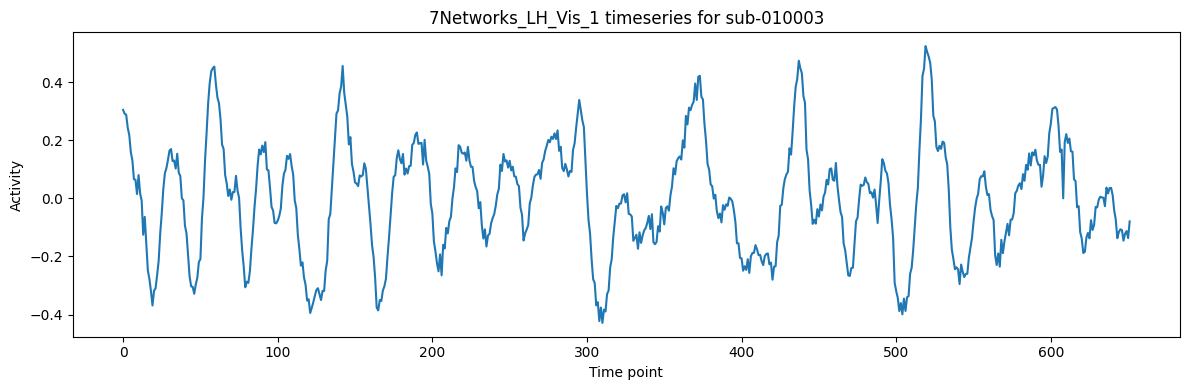

In [19]:
# Create a new figure (plotting canvas)
# figsize=(12, 4) means 12 inches wide and 4 inches tall
plt.figure(figsize=(12, 4))

# Plot the timeseries values as a line graph
# The x-axis will automatically use the row number (0, 1, 2, ...)
# The y-axis will show the activity values for this brain region
plt.plot(region_ts)

# Add a title to the plot
# The f-string inserts the region name and subject ID into the title
plt.title(f"{region_name} timeseries for {subject_id}")

# Label the x-axis
# Each point corresponds to one fMRI time point
plt.xlabel("Time point")

# Label the y-axis
# These values represent brain activity in the selected region
plt.ylabel("Activity")

# Adjust spacing so labels and titles fit neatly inside the figure
plt.tight_layout()

# Display the completed plot
plt.show()

### Understanding the plot

The `plot()` function draws a line connecting the activity values recorded at each time point.

In this figure:

- the **x-axis** represents time points in the fMRI scan
- the **y-axis** represents activity in the selected brain region
- each point on the line corresponds to one row in the subject's timeseries dataframe

Notice how the signal rises and falls over time. These fluctuations are the fMRI signal measured from this brain region. Later, we will compare these fluctuations across different brain regions to estimate functional connectivity.